# 🎬 Movie Rating Prediction – Final Assignment Part 2
**Gil Hatiel & Liel Leone | Machine Learning Course**

## ⚙️ Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Style – מוגדר פעם אחת, חל על כל הגרפים
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size']      = 13
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.titlepad']     = 10

SEED = 42
np.random.seed(SEED)

GREEN  = '#2ecc71'
RED    = '#e74c3c'
BLUE   = '#3498db'
ORANGE = '#f39c12'

print('✅ All set!')

✅ All set!


---
## 🔍 Part 1: Exploratory Data Analysis (EDA)

### What are we looking at?
Before touching anything, we need to understand what we have.
Three questions to answer:
1. What is the shape of the data?
2. What do the values look like?
3. What is missing?

In [2]:
# ---------------------------------------------------------------
# 1.0  Load & First Look
# ---------------------------------------------------------------
df_raw = pd.read_csv('dataset.csv', low_memory=False)

In [3]:
# כמה שורות ועמודות יש?
print(f'📦 Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

📦 Shape: 133,884 rows × 13 columns


In [4]:
# הצגת 5 שורות אקראיות
df_raw.sample(5, random_state=SEED)

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
3115,tt1507306,Jangan Pandang Belakang Congkak,2009.0,"Comedy,Fantasy,Horror","['nm0784094', 'nm3603389', 'nm3603159', 'nm360...",90.0,3.4,NaN,NaN,87.0,NaN,NaN,NaN
14399,tt7520068,Kolej Havasi,2019.0,Documentary,"['nm11454310', 'nm11454313', 'nm11454314', 'nm...",105.0,8.7,NaN,NaN,259.0,NaN,NaN,NaN
132162,tt7021508,Honey: Rise Up and Dance,2018.0,"Drama,Music","nm3692520, nm7005977, nm2057826, nm0496980, nm...",100.0,5.0,NaN,NaN,1013.0,NaN,NaN,NaN
94863,tt22898390,Anmitsu hime: Yôjutsu kurabe no maki,1954.0,NaN,"['nm0950825', 'nm0473530', 'nm1090569', 'nm178...",65.0,NaN,NaN,NaN,0.0,NaN,NaN,"Anmitsu Hime ( あんみつ姫 ; ""Princess Anmitsu "") is..."
27537,tt0466456,Midsummer Madness,2007.0,"[""Comedy"", ""Drama"", ""Romance""]","[""nm0684500"", ""nm0920366"", ""nm1616309"", ""nm060...",94.0,5.9,Latvian,Latvia,625.0,3.5,NaN,NaN


In [5]:
# מה סוג הנתונים בכל עמודה
df_raw.dtypes

tconst              object
primaryTitle        object
startYear          float64
genres              object
lead_actors_ids     object
runtimeMinutes     float64
averageRating      float64
Language            object
Country             object
numVotes           float64
budget              object
BoxOffice          float64
plot                object
dtype: object

In [6]:
# ---------------------------------------------------------------
# 1.2  Statistical summary רק על העמודות המספריות
# ---------------------------------------------------------------

df_raw.describe().round(2)

,startYear,runtimeMinutes,averageRating,numVotes,BoxOffice
count,133884.00,133884.00,115560.00,124762.00,1.791600e+04
mean,1995.64,97.24,6.07,7562.01,4.705076e+07
std,64.75,22.92,1.29,54834.44,2.894113e+09
min,0.00,60.00,1.00,0.00,0.000000e+00
25%,1982.00,84.00,5.30,36.00,1.000000e+00
50%,2007.00,93.00,6.20,173.00,7.900000e+00
75%,2017.00,106.00,7.00,879.00,6.095000e+01
max,2026.00,300.00,10.00,3186698.00,3.120000e+11


In [7]:
 ## 1.3  Missing values analysis נבדוק כמה חסר בכל עמודה
missing = pd.DataFrame({
    'missing_count': df_raw.isnull().sum(),
    'missing_%':     (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('missing_%', ascending=False)

display(missing)

,missing_count,missing_%
budget,117334,87.6
BoxOffice,115968,86.6
Country,80203,59.9
Language,78162,58.4
plot,74215,55.4
averageRating,18324,13.7
lead_actors_ids,10030,7.5
numVotes,9122,6.8
genres,2573,1.9
tconst,0,0.0


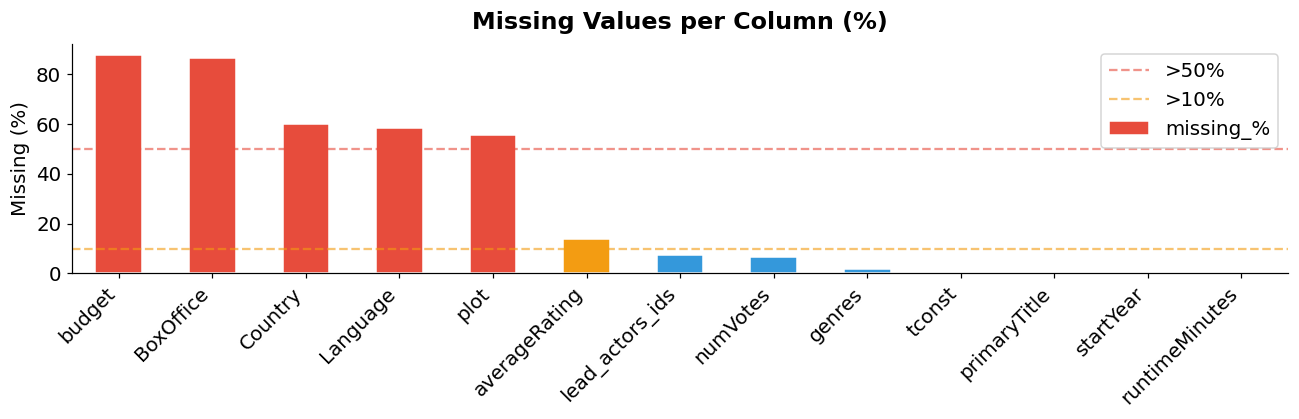

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
colors = [RED if p > 50 else ORANGE if p > 10 else BLUE
          for p in missing['missing_%']]
missing['missing_%'].plot(kind='bar', ax=ax, 
                          color=colors, edgecolor='white')
ax.set_title('Missing Values per Column (%)', fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.axhline(50, color=RED,    linestyle='--', alpha=0.6, label='>50%')
ax.axhline(10, color=ORANGE, linestyle='--', alpha=0.6, label='>10%')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

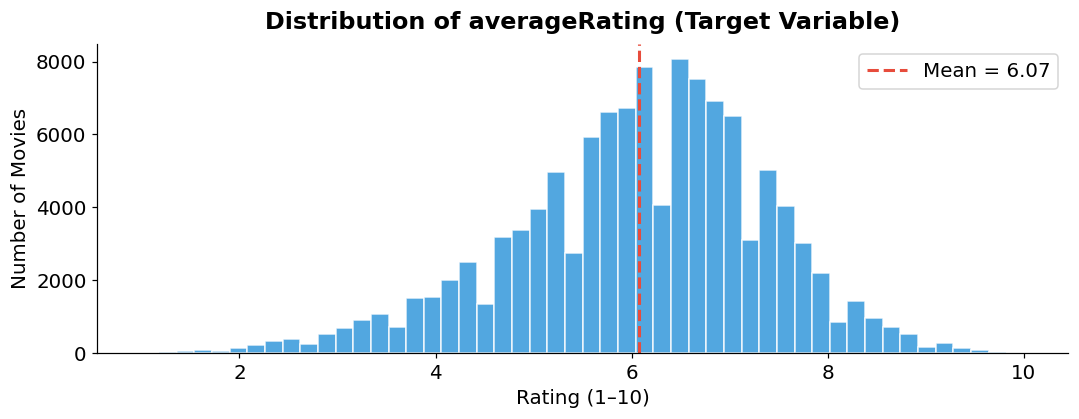

In [9]:
# 1.4  Target variable – averageRating
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_raw['averageRating'].dropna(), bins=50,
        color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(df_raw['averageRating'].mean(), color=RED,
           linestyle='--', linewidth=2,
           label=f'Mean = {df_raw["averageRating"].mean():.2f}')
ax.set_title('Distribution of averageRating (Target Variable)', 
             fontweight='bold')
ax.set_xlabel('Rating (1–10)')
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.show()

### Initial Data Understanding

The dataset contains 133,884 movie records and 13 columns.  
The target variable is `averageRating`, which represents the average IMDb rating of each movie.

From the initial inspection, the dataset contains both numerical and categorical/textual features.  
Numerical columns include `startYear`, `runtimeMinutes`, `averageRating`, `numVotes`, and `BoxOffice`.  
Categorical or textual columns include `tconst`, `primaryTitle`, `genres`, `lead_actors_ids`, `Language`, `Country`, `budget`, and `plot`.

The target variable `averageRating` ranges from 1 to 10, with an average value of approximately 6.07 and a median of 6.2.  
This suggests that most movies in the dataset are rated around the middle-high range, while very low or very high ratings are less common.

A major issue in the dataset is missing values. Some columns have a very high percentage of missing data, especially `budget`, `BoxOffice`, `Country`, `Language`, and `plot`.  
Therefore, simply removing rows with missing values would cause a significant loss of data. Later stages should handle missing values using imputation or by creating informative missingness indicators.

The column `budget` is stored as an object rather than a numerical column, meaning it requires cleaning before it can be used as a feature.  
In addition, `startYear` contains suspicious values such as 0, which should be handled during the data preparation stage.

Finally, although `numVotes` and `BoxOffice` appear in the dataset, they will not be used as model features because they represent information that is only available after a movie is released and may cause data leakage.

In [10]:
# 1.5  Data Quality Checks
df_raw.duplicated().sum()

np.int64(0)

In [11]:
# כפילויות לפי tconst
df_raw['tconst'].duplicated().sum()

np.int64(0)

In [12]:
# ערכי startYear חשודים
df_raw[df_raw['startYear'] < 1888]

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
64465,tt10209920,Alien Wars: Judgement Day,0.0,['Sci-Fi'],"['nm3782241', 'nm0357405', 'nm0245223', 'nm177...",90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64533,tt3580466,Alhambra Decree 1492,0.0,"['Adventure', 'Drama', 'History']","['nm0537631', 'nm0001934', 'nm2454994', 'nm106...",110.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64627,tt4764536,Action Not Words,0.0,['Action'],"['nm0584473', 'nm4106347', 'nm2335825', 'nm914...",91.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64687,tt3116542,Alam High School,0.0,"['Documentary', 'History']",['nm0013037'],150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64828,tt7727364,All That Ends,0.0,['Drama'],['nm9164025'],90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71658,tt14998708,Agent Surya,0.0,"['Crime', 'Mystery', 'Thriller']",['nm8242827'],120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71761,tt41141748,All That's Left,0.0,"['Drama', 'Sci-Fi']","['nm7956133', 'nm6672073', 'nm15672591', 'nm09...",85.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71816,tt1662622,Aleya's Tango: Dreams of a Vampyre,0.0,"['Drama', 'Fantasy', 'Musical']","['nm3935935', 'nm3223702', 'nm3927793', 'nm392...",82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71855,tt35681860,Almost Blue,0.0,"['Crime', 'Drama']","['nm17002694', 'nm17002692', 'nm17002697', 'nm...",88.0,NaN,Italian,Italy,NaN,NaN,NaN,NaN


In [13]:
# כמה ז'אנרים ייחודיים יש?
df_raw['genres'].nunique()

2225

In [14]:
# אילו זאנרים הכי נפוצים בדאטה?
genres_split = df_raw['genres'].dropna().str.replace(r"[\[\]'\"]", '', regex=True)
genres_split = genres_split.str.split(',').explode().str.strip()
genres_split.value_counts().head(15)

genres
Drama          64056
Comedy         35201
Documentary    18264
Romance        16584
Action         14862
Crime          13017
Thriller       12296
Horror         10371
Adventure       8657
Mystery         5874
Family          5332
Biography       4641
Fantasy         4414
Music           3765
History         3757
Name: count, dtype: int64

In [15]:
# האם יש סרטים עם כמה ז'אנרים?
df_raw['genres'].dropna().sample(10, random_state=SEED)

99501                           Horror
52515                       ['Comedy']
123260                          Comedy
56892                           Comedy
10238                           Comedy
22659     ["Comedy", "Crime", "Drama"]
31858             ['Drama', 'Romance']
92674                           Comedy
32120                        ['Drama']
129685                   Comedy,Horror
Name: genres, dtype: object

> **Two formats detected:** `"Comedy,Horror"` and `['Drama', 'Romance']`.
Brackets and quotes must be cleaned and unified before processing.

In [16]:
df_raw['Country'].dropna().sample(25, random_state=SEED)

75971                                       United States
48319                                        Soviet Union
119901                                          Not Found
22195                                       United States
24169                                              Sweden
89825                                       United States
122771                                              India
59948                                          Azerbaijan
43544                            United States of America
112694                                      United States
117104                                      United States
50198                                    Hong Kong, China
94336                                         Philippines
41969                                      United Kingdom
36977                                              Canada
83028                                      United Kingdom
48003                                              Brazil
72512         

> The Country column contains inconsistent notations for the same country (e.g., "United States" vs. "United States of America" vs. "US"), multi-country entries separated by commas, and citation artifacts like Italy[1]. Cleaning and normalization are required before determining the Top 15 countries.

In [17]:
# בעיות שזוהו בעמודת Country
print('Multi-country entries:', df_raw['Country'].str.contains(',', na=False).sum())
print('List format:',           df_raw['Country'].str.startswith('[', na=False).sum())
print('Citation artifacts:',    df_raw['Country'].str.contains(r'\[\d+\]', na=False, regex=True).sum())

Multi-country entries: 2037
List format: 355
Citation artifacts: 73


In [18]:
df_raw['Country'].fillna('').str.replace(r"[\[\]'\"]", '', regex=True).str.strip().value_counts().head(15)

Country
                  80203
United States     19431
India              7132
United Kingdom     2644
France             1740
Italy              1680
Not Found          1645
Japan              1522
Canada             1154
Spain               747
South Korea         735
Germany             696
Hong Kong           689
Australia           621
Mexico              508
Name: count, dtype: int64

Country column normalization: the column contained inconsistent notations 
(e.g. "US", "U.S", "USA" for the same country). I asked Claude to suggest 
possible variants for each country. I then manually validated each variant 
against the actual data and confirmed the final Top 15 countries and their 
counts after unification.

In [19]:
# כמה ערכים ייחודיים יש בעמודת Country?
df_raw['Country'].nunique()

2532

In [20]:
# מה נראה ב-lead_actors_ids?
df_raw['lead_actors_ids'].dropna().sample(5, random_state=SEED)

82437     ['nm0680983', 'nm0644897', 'nm0013037', 'nm185...
83108     ['nm0846070', 'nm0814033', 'nm0434223', 'nm071...
50652     ['nm0058181', 'nm0087142', 'nm0160945', 'nm019...
80415     ['nm4404734', 'nm0911854', 'nm4178142', 'nm523...
121940    nm1156207, nm4539846, nm2636694, nm4540117, nm...
Name: lead_actors_ids, dtype: object

> **lead_actors_ids column:** two formats detected –
> list format `['nm001', 'nm002']` and plain string `nm001, nm002`.
> Regex will be used to count actors correctly in both cases.

In [21]:
# מספר שחקנים לסרט – regex עובד על שני הפורמטים
n_act = df_raw['lead_actors_ids'].apply(
    lambda x: len(re.findall(r'nm\d+', str(x))) if pd.notna(x) else np.nan
)
n_act.value_counts(dropna=False).sort_index()

lead_actors_ids
0.0     8873
1.0     3934
2.0     3599
3.0     5302
4.0     5832
5.0    96314
NaN    10030
Name: count, dtype: int64

In [22]:
# כמה ערכים יש בעמודת Language?
print(f'ערכים ייחודיים: {df_raw["Language"].nunique():,}')
print(f'חסרים: {df_raw["Language"].isna().sum():,} ({df_raw["Language"].isna().sum()/len(df_raw)*100:.1f}%)')

ערכים ייחודיים: 2,936
חסרים: 78,162 (58.4%)


In [23]:
# מה השפות הנפוצות ביותר?
df_raw['Language'].value_counts().head(15)

Language
English      26332
Hindi         2344
French        2217
Spanish       1953
Italian       1822
Not Found     1645
Japanese      1479
Tamil         1294
German        1100
Telugu        1032
Malayalam     1009
Russian        763
Korean         685
Cantonese      529
Mandarin       501
Name: count, dtype: int64

In [24]:
# כמה סרטים יש עם אנגלית (כולל סרטים עם כמה שפות)
has_english = df_raw['Language'].str.contains('english', case=False, na=False).sum()
print(f'סרטים עם אנגלית: {has_english:,} ({has_english/len(df_raw)*100:.1f}%)')

סרטים עם אנגלית: 29,432 (22.0%)


In [25]:
crew  = pd.read_csv('title.crew.tsv',  sep='\t', na_values='\\N',
                    usecols=['tconst', 'directors'])
names = pd.read_csv('name.basics.tsv', sep='\t', na_values='\\N',
                    usecols=['nconst', 'primaryName'])

In [26]:
crew['director_id'] = crew['directors'].str.split(',').str[0]
crew = crew.merge(names, left_on='director_id', right_on='nconst', how='left')
df_raw = df_raw.merge(crew[['tconst','primaryName']], on='tconst', how='left')
df_raw = df_raw.rename(columns={'primaryName': 'director'})

# כמה חסרים?
missing = df_raw['director'].isna().sum()
print(f'חסרים: {missing:,} ({missing/len(df_raw)*100:.1f}%)')

# top במאים
df_raw['director'].value_counts().head(20)

חסרים: 1,267 (0.9%)


director
Kinya Ogawa           103
Jesús Franco           84
Satoru Kobayashi       78
William Beaudine       76
Michael Curtiz         60
Lesley Selander        60
Osman F. Seden         56
Yōji Yamada            54
Lloyd Bacon            53
Kaoru Umezawa          53
Priyadarshan           52
Lew Landers            51
Masahiro Makino        50
Sakae Nitta            49
Atıf Yılmaz            48
Gérard Courant         47
Mamoru Watanabe        47
K. Raghavendra Rao     46
Frank McDonald         45
Orhan Aksoy            45
Name: count, dtype: int64

**Director Quality Feature:** I asked Claude for a list of internationally acclaimed directors based on external knowledge (Oscar wins, IMDb Top 250, critical recognition) — without using `averageRating` from our dataset. I then verified their presence in the data to create a binary `director_acclaimed` feature.

In [27]:
ACCLAIMED_DIRECTORS = [
    'John Ford', 'Alfred Hitchcock', 'Ingmar Bergman',
    'Jean-Luc Godard', 'Federico Fellini', 'Orson Welles',
    'Martin Scorsese', 'Steven Spielberg', 'Billy Wilder',
    'Akira Kurosawa', 'Francis Ford Coppola', 'Satyajit Ray',
    'Hayao Miyazaki', 'Christopher Nolan', 'Stanley Kubrick',
    'Fritz Lang', 'Frank Capra', 'John Huston', 'Vittorio De Sica'
]

df_raw['director_acclaimed'] = df_raw['director'].isin(ACCLAIMED_DIRECTORS).astype(int)
df_raw['director_missing']   = df_raw['director'].isna().astype(int)

print(f"director_acclaimed: {df_raw['director_acclaimed'].sum()} סרטים")
print(f"director_missing:   {df_raw['director_missing'].sum()} סרטים")

director_acclaimed: 423 סרטים
director_missing:   1267 סרטים


In [28]:
# שחקנים לפי כמות הופעות (ללא שימוש ב-rating)
actors_flat = df_raw[['lead_actors_ids']].dropna().copy()
actors_flat['nconst'] = actors_flat['lead_actors_ids'].apply(
    lambda x: re.findall(r'nm\d+', str(x))
)
actors_flat = actors_flat.explode('nconst')

actor_counts = actors_flat.groupby('nconst').size()\
    .reset_index(name='count')\
    .query('count >= 10')\
    .sort_values('count', ascending=False)

names = pd.read_csv('name.basics.tsv', sep='\t', na_values=r'\N',
                    usecols=['nconst','primaryName'])

actor_counts = actor_counts.merge(names, on='nconst').head(10)
print(actor_counts[['primaryName','count']].to_string())

          primaryName  count
0        Brahmanandam    197
1            Mohanlal    189
2           Mammootty    180
3         Prakash Raj    143
4        Eric Roberts    136
5         Anupam Kher    133
6              Nassar    128
7  Mithun Chakraborty    128
8          Dharmendra    121
9    Amitabh Bachchan    117


להוסיף הסבר על שחקנים מוכרים מהקלוד#

In [29]:
# שחקנים מוכרים לפי ידע חיצוני (Oscar, AFI, הכרה בינלאומית)
ACCLAIMED_ACTORS = [
    'Amitabh Bachchan', 'Kamal Haasan', 'Gérard Depardieu',
    'Robert De Niro', 'Humphrey Bogart', 'Anthony Hopkins',
    'Tom Hanks', 'Dustin Hoffman', 'Jack Nicholson',
    'Al Pacino', 'Meryl Streep', 'Cate Blanchett',
    'Marlon Brando', 'Daniel Day-Lewis', 'Audrey Hepburn'
]

actor_check = actors_flat.merge(names, on='nconst')
actor_check[actor_check['primaryName'].isin(ACCLAIMED_ACTORS)]\
    .groupby('primaryName').size().sort_values(ascending=False)

primaryName
Amitabh Bachchan    117
Kamal Haasan        108
Gérard Depardieu     96
Robert De Niro       76
Humphrey Bogart      50
Anthony Hopkins      45
Tom Hanks            45
Dustin Hoffman       40
Jack Nicholson       37
Al Pacino            35
Meryl Streep         32
Cate Blanchett       31
Marlon Brando        25
Daniel Day-Lewis     16
Audrey Hepburn       15
dtype: int64

In [30]:
# בדיקה האם אחד מהשחקנים נמצא ברשימות וכמה 
acclaimed_ids = set(names[names['primaryName'].isin(ACCLAIMED_ACTORS)]['nconst'])

df_raw['actor_acclaimed'] = df_raw['lead_actors_ids'].apply(
    lambda x: int(any(nm in acclaimed_ids 
                      for nm in re.findall(r'nm\d+', str(x))))
)

print(f"actor_acclaimed: {df_raw['actor_acclaimed'].sum()} סרטים")

actor_acclaimed: 708 סרטים


In [31]:
# הרץ פעם אחת כדי לקבל את ה-IDs
ACCLAIMED_ACTORS = ['Amitabh Bachchan', 'Kamal Haasan', 'Gérard Depardieu',
        'Robert De Niro', 'Humphrey Bogart', 'Anthony Hopkins',
        'Tom Hanks', 'Dustin Hoffman', 'Jack Nicholson',
        'Al Pacino', 'Meryl Streep', 'Cate Blanchett',
        'Marlon Brando', 'Daniel Day-Lewis', 'Audrey Hepburn']
print(names[names['primaryName'].isin(ACCLAIMED_ACTORS)][['primaryName','nconst']])

               primaryName      nconst
6          Humphrey Bogart   nm0000007
7            Marlon Brando   nm0000008
29          Audrey Hepburn   nm0000030
133         Robert De Niro   nm0000134
157              Tom Hanks   nm0000158
162         Dustin Hoffman   nm0000163
163        Anthony Hopkins   nm0000164
196         Jack Nicholson   nm0000197
198              Al Pacino   nm0000199
357       Daniel Day-Lewis   nm0000358
366       Gérard Depardieu   nm0000367
657           Meryl Streep   nm0000658
820       Amitabh Bachchan   nm0000821
947         Cate Blanchett   nm0000949
332647        Kamal Haasan   nm0352032
1837160    Anthony Hopkins  nm10984573
2137986     Jack Nicholson  nm11297332
2159897    Anthony Hopkins  nm11320299
2608656    Anthony Hopkins  nm11790875
2718824     Jack Nicholson  nm11907710
2733199    Anthony Hopkins  nm11922777
4191713      Marlon Brando  nm13489435
5203953    Anthony Hopkins  nm14652177
6057485     Jack Nicholson  nm15639779
7054402     Jack Nicholso

**Acclaimed Actors — Feature Engineering Note**

The `actor_acclaimed` feature was created based on external knowledge, not derived from the dataset's ratings.
A list of well-known acclaimed actors was compiled, and each actor's name was manually matched to their IMDb numeric `nm` ID by searching the dataset.

Note: some actors appear under **multiple different nm IDs** in IMDb (duplicate entries for the same person). All known ID variants are included in the set to ensure complete matching.

## 🧹 Part 2: `prepare_data` Function

This function receives the raw DataFrame (as collected in Part 1) and returns 
a clean, model-ready DataFrame containing only the relevant features.



In [64]:
def prepare_data(df):
    import os
    df = df.copy()

    # ---------------------------------------------------------------
    # הורדת עמודות leakage
    # ---------------------------------------------------------------
    if 'averageRating' in df.columns:
        df = df.dropna(subset=['averageRating'])
    leakage_cols = ['numVotes', 'BoxOffice']
    df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

    # ---------------------------------------------------------------
    # שנת יצירה — מילוי חציון לפני חישוב עשור
    # ---------------------------------------------------------------
    df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce')
    df.loc[df['startYear'] < 1888, 'startYear'] = np.nan
    df['year_missing'] = df['startYear'].isna().astype(int)
    df['decade'] = (df['startYear'] // 10 * 10)  # NaN כשאין שנה

    # ---------------------------------------------------------------
    # זמן ריצה — binning
    # ---------------------------------------------------------------
    df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')
    def categorize_runtime(val):
        if pd.isna(val) or val == 0: return 'no_data'
        elif val <= 80:              return 'short'
        elif val <= 120:             return 'medium'
        else:                        return 'long'
    df['runtime_cat'] = df['runtimeMinutes'].apply(categorize_runtime)

    # ---------------------------------------------------------------
    #  ז'אנרים - נפוצים בתעשיית הקולנוע העולמית
    # ---------------------------------------------------------------
    SELECTED_GENRES = [
        'Drama', 'Comedy', 'Thriller', 'Action', 'Romance',
        'Horror', 'Crime', 'Documentary', 'Adventure', 'Animation',
        'Fantasy', 'Biography', 'Mystery', 'Sci-Fi', 'Family'
    ]
    def normalize_genres(val):
        if pd.isna(val) or str(val).strip() == '\\N': return ''
        val = re.sub(r"[\[\]'\"]", '', str(val))
        genres = [g.strip().title() for g in val.split(',') if g.strip()]
        return ','.join(sorted(genres))

    df['genres'] = df['genres'].apply(normalize_genres)
    df['n_genres'] = df['genres'].apply(lambda x: len(x.split(',')) if x else 0)
    for genre in SELECTED_GENRES:
        col = f'genre_{genre.lower().replace("-","_").replace(" ","_")}'
        df[col] = df['genres'].apply(
            lambda x, g=genre: int(g in x.split(',')) if x else 0
        )

    # ---------------------------------------------------------------
    # מדינה — נרמול + עמודות בינאריות קבועות
    # ---------------------------------------------------------------
    COUNTRY_ALIASES = {
        'Usa': 'United States', 'Us': 'United States',
        'U.S.': 'United States', 'U.S.A.': 'United States',
        'United States Of America': 'United States',
        'Uk': 'United Kingdom', 'Great Britain': 'United Kingdom',
        'England': 'United Kingdom',
        'Ussr': 'Russia', 'Soviet Union': 'Russia',
        'West Germany': 'Germany', 'East Germany': 'Germany',
        'Not Found': 'Unknown',
    }
    # מדינות שנבחרו על בסיס נפיצות גלובלית בתעשיית הקולנוע
    SELECTED_COUNTRIES = [
        'United States', 'United Kingdom', 'France', 'Germany',
        'India', 'Italy', 'Japan', 'Canada', 'Australia',
        'Spain', 'China', 'South Korea', 'Russia', 'Brazil', 'Mexico'
    ]
    def extract_primary_country(val):
        if pd.isna(val): return np.nan
        val = re.sub(r'\[\d+\]', '', str(val))
        val = re.sub(r"[\[\]'\"]", '', val)
        parts = re.split(r'[,/]', val)
        country = parts[0].strip().title()
        if not country: return np.nan
        return COUNTRY_ALIASES.get(country, country)

    df['_country_clean'] = df['Country'].apply(extract_primary_country)
    df['country_group']  = df['_country_clean'].apply(
    lambda x: x              if (pd.notna(x) and x in SELECTED_COUNTRIES)
         else 'Other_Country' if pd.notna(x)   # ← מדינה ידועה אבל לא בטופ 15
         else 'Unknown'                         # ← מדינה חסרה
      )
    df = df.drop(columns=['_country_clean'])

    # ---------------------------------------------------------------
    # תקציב
    # ---------------------------------------------------------------
    budget_clean = pd.to_numeric(
        df['budget'].str.replace(r'[$,]', '', regex=True), errors='coerce'
    )
    df['budget_reported'] = budget_clean.notna().astype(int)

    # ---------------------------------------------------------------
    # שפה
    # ---------------------------------------------------------------
    df['is_english'] = df['Language'].str.contains(
        'English', case=False, na=False
    ).astype(int)

    # ---------------------------------------------------------------
    # עלילה
    # ---------------------------------------------------------------
    EMPTY_PLOT_PATTERNS = r'(?i)(no plot|not available|n/a|none|plot unknown|no synopsis|not found|^\s*$)'
    df['has_plot'] = (
        df['plot'].notna() &
        ~df['plot'].str.strip().str.match(EMPTY_PLOT_PATTERNS, na=False)
    ).astype(int)
    df['plot_length'] = df['plot'].apply(
        lambda x: len(str(x).split())
        if pd.notna(x) and not re.match(EMPTY_PLOT_PATTERNS, str(x).strip())
        else 0
    )

    # ---------------------------------------------------------------
    # במאי
    # ---------------------------------------------------------------
    ACCLAIMED_DIRECTORS = [
        'John Ford', 'Alfred Hitchcock', 'Ingmar Bergman', 'Jean-Luc Godard',
        'Federico Fellini', 'Orson Welles', 'Martin Scorsese', 'Steven Spielberg',
        'Billy Wilder', 'Akira Kurosawa', 'Francis Ford Coppola', 'Satyajit Ray',
        'Hayao Miyazaki', 'Christopher Nolan', 'Stanley Kubrick',
        'Fritz Lang', 'Frank Capra', 'John Huston', 'Vittorio De Sica'
    ]

    if 'director' in df.columns:
        df['director_acclaimed'] = df['director'].isin(ACCLAIMED_DIRECTORS).astype(int)
        df['director_missing']   = df['director'].isna().astype(int)

    elif 'tconst' in df.columns:
        _crew  = None
        _names = None

        if os.path.exists('title.crew.tsv') and os.path.exists('name.basics.tsv'):
            _crew  = pd.read_csv('title.crew.tsv',  sep='\t', na_values='\\N',
                                 usecols=['tconst', 'directors'])
            _names = pd.read_csv('name.basics.tsv', sep='\t', na_values='\\N',
                                 usecols=['nconst', 'primaryName'])

        if _crew is not None and _names is not None:
            _crew['director_id'] = _crew['directors'].str.split(',').str[0]
            _crew = _crew.merge(_names, left_on='director_id', right_on='nconst', how='left')
            _dir_map = dict(zip(_crew['tconst'], _crew['primaryName']))
            _director = df['tconst'].map(_dir_map)
            df['director_acclaimed'] = _director.isin(ACCLAIMED_DIRECTORS).astype(int)
            df['director_missing']   = _director.isna().astype(int)
        else:
            df['director_acclaimed'] = 0
            df['director_missing']   = 1

    else:
        df['director_acclaimed'] = 0
        df['director_missing']   = 1

    # ---------------------------------------------------------------
    # שחקנים
    # ---------------------------------------------------------------
    ACCLAIMED_ACTOR_IDS = {
        'nm0000007', 'nm0000008', 'nm13489435', 'nm0000030', 'nm4899845',
        'nm5375041', 'nm9219530', 'nm0000134', 'nm0000158', 'nm0000163',
        'nm17316570', 'nm0000164', 'nm10984573', 'nm11320299', 'nm11790875',
        'nm11922777', 'nm14652177', 'nm4577647', 'nm6145332', 'nm7018013',
        'nm9922244', 'nm0000197', 'nm11297332', 'nm11907710', 'nm15639779',
        'nm16788446', 'nm3713421', 'nm5504786', 'nm7368184', 'nm0000199',
        'nm6950605', 'nm0000358', 'nm0000367', 'nm0000658', 'nm0000821',
        'nm0000949', 'nm0352032'
    }

    if 'lead_actors_ids' in df.columns:
        df['actors_missing']  = df['lead_actors_ids'].isna().astype(int)
        df['actor_acclaimed'] = df['lead_actors_ids'].apply(
            lambda x: int(any(nm in ACCLAIMED_ACTOR_IDS
                             for nm in re.findall(r'nm\d+', str(x))))
        )
    else:
        df['actors_missing']  = 1
        df['actor_acclaimed'] = 0

    # ---------------------------------------------------------------
    # הורדת עמודות גולמיות
    # ---------------------------------------------------------------
    drop_cols = ['tconst', 'primaryTitle', 'lead_actors_ids',
                 'Language', 'budget', 'plot', 'director',
                 'runtimeMinutes', 'genres', 'Country','startYear']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # ---------------------------------------------------------------
    # averageRating לעמודה האחרונה אם קיימת
    # ---------------------------------------------------------------
    if 'averageRating' in df.columns:
        target = df.pop('averageRating')
        df['averageRating'] = target

    return df

In [65]:
# בדיקה על הדאטה המלא
df_processed = prepare_data(df_raw)
print(f'Shape: {df_processed.shape}')
print(f'Columns ({len(df_processed.columns)}): {df_processed.columns.tolist()}')

Shape: (115560, 29)
Columns (29): ['director_acclaimed', 'director_missing', 'actor_acclaimed', 'year_missing', 'decade', 'runtime_cat', 'n_genres', 'genre_drama', 'genre_comedy', 'genre_thriller', 'genre_action', 'genre_romance', 'genre_horror', 'genre_crime', 'genre_documentary', 'genre_adventure', 'genre_animation', 'genre_fantasy', 'genre_biography', 'genre_mystery', 'genre_sci_fi', 'genre_family', 'country_group', 'budget_reported', 'is_english', 'has_plot', 'plot_length', 'actors_missing', 'averageRating']


In [66]:
# ── הכנת הדאטה ───────────────────────────────────────────────────────────
# מריצים את פונקציית ההכנה ומוודאים ש-averageRating נמצאת בעמודה האחרונה

df_prepared = prepare_data(df_raw)

X = df_prepared.iloc[:, :-1]
y = df_prepared.iloc[:, -1]


In [67]:
# ── חלוקה לאימון ומבחן ───────────────────────────────────────────────────
# 80% אימון, 20% מבחן
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

In [68]:
numerical_vars   = ['decade', 'n_genres', 'plot_length']
categorical_vars = ['runtime_cat', 'country_group']

genre_vars = [
    f'genre_{g.lower().replace("-","_").replace(" ","_")}'
    for g in [
        'Drama', 'Comedy', 'Thriller', 'Action', 'Romance',
        'Horror', 'Crime', 'Documentary', 'Adventure', 'Animation',
        'Fantasy', 'Biography', 'Mystery', 'Sci-Fi', 'Family'
    ]
]

binary_vars = [
    'budget_reported', 'is_english', 'has_plot',
    'director_acclaimed', 'director_missing',
    'actor_acclaimed', 'actors_missing', 'year_missing'
] + genre_vars

pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

pipe_cat = Pipeline([
    ('OHE', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num',    pipe_num,      numerical_vars),
    ('cat',    pipe_cat,      categorical_vars),
    ('binary', 'passthrough', binary_vars)
])

In [69]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        ElasticNet(max_iter=10000, random_state=SEED))
])

In [70]:
from sklearn import set_config
set_config(display='diagram')

# הצגת Pipeline של ElasticNet
display(pipeline)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
param_grid_en = {
    'model__alpha':    [0.001, 0.01, 0.1, 1.0],
    'model__l1_ratio': [0.1,0.2, 0.5, 0.8]
}

gs_en = GridSearchCV(
    pipeline, param_grid_en,
    cv=10,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
gs_en.fit(X_train, y_train)

print("✅ ElasticNet — פרמטרים אופטימליים:", gs_en.best_params_)
print(f"   RMSE (GridSearch CV): {-gs_en.best_score_:.4f}")

Fitting 10 folds for each of 16 candidates, totalling 160 fits
✅ ElasticNet — פרמטרים אופטימליים: {'model__alpha': 0.001, 'model__l1_ratio': 0.1}
   RMSE (GridSearch CV): 1.1329


In [73]:
# ================================================================
# שלב 2 – ElasticNet: דיווח ביצועים רשמי – 10-fold CV
# ================================================================

cv_en = cross_validate(
    gs_en.best_estimator_,
    X, y,
    cv=KFold(n_splits=10, shuffle=True, random_state=SEED),
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'r2':   'r2'
    }
)

print("📊 ElasticNet — 10-Fold Cross Validation Results:")
print(f"   RMSE: {-cv_en['test_rmse'].mean():.4f} ± {cv_en['test_rmse'].std():.4f}")
print(f"   MAE:  {-cv_en['test_mae'].mean():.4f}  ± {cv_en['test_mae'].std():.4f}")
print(f"   R²:   {cv_en['test_r2'].mean():.4f}  ± {cv_en['test_r2'].std():.4f}")

📊 ElasticNet — 10-Fold Cross Validation Results:
   RMSE: 1.1320 ± 0.0101
   MAE:  0.8670  ± 0.0069
   R²:   0.2332  ± 0.0074


In [42]:
from sklearn.ensemble import RandomForestRegressor

# ── מודל Random Forest ────────────────────────────────────────────────────
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        RandomForestRegressor(random_state=SEED))
])

In [43]:
# הצגת Pipeline של Random Forest  
display(pipeline_rf)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
# ================================================================
# שלב 3 – Random Forest: מציאת פרמטרים אופטימליים
# ================================================================

param_grid_rf = {
    'model__n_estimators':      [200, 300],
    'model__max_depth':         [10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
}

gs_rf = GridSearchCV(
    pipeline_rf, param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
gs_rf.fit(X_train, y_train)

print("✅ Random Forest — פרמטרים אופטימליים:", gs_rf.best_params_)
print(f"   RMSE (GridSearch CV): {-gs_rf.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
✅ Random Forest — פרמטרים אופטימליים: {'model__max_depth': 20, 'model__min_samples_split': 10, 'model__n_estimators': 300}
   RMSE (GridSearch CV): 1.1183


In [62]:
# ================================================================
# שלב 4 – Random Forest: דיווח ביצועים רשמי – 10-fold CV
# ================================================================

cv_rf = cross_validate(
    gs_rf.best_estimator_,
    X, y,
    cv=KFold(n_splits=10, shuffle=True, random_state=SEED),
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'r2':   'r2'
    }
)

print("📊 Random Forest — 10-Fold Cross Validation Results:")
print(f"   RMSE: {-cv_rf['test_rmse'].mean():.4f} ± {cv_rf['test_rmse'].std():.4f}")
print(f"   MAE:  {-cv_rf['test_mae'].mean():.4f}  ± {cv_rf['test_mae'].std():.4f}")
print(f"   R²:   {cv_rf['test_r2'].mean():.4f}  ± {cv_rf['test_r2'].std():.4f}")

📊 Random Forest — 10-Fold Cross Validation Results:
   RMSE: 1.1142 ± 0.0094
   MAE:  0.8474  ± 0.0075
   R²:   0.2571  ± 0.0061


In [47]:
from sklearn.model_selection import cross_val_predict

KF = KFold(n_splits=10, shuffle=True, random_state=SEED)

# ================================================================
# תחזיות CV לשני המודלים
# ================================================================
y_pred_rf = cross_val_predict(
    estimator=gs_rf.best_estimator_,
    X=X, y=y, cv=KF, n_jobs=2
)
y_pred_en = cross_val_predict(
    estimator=gs_en.best_estimator_,
    X=X, y=y, cv=KF, n_jobs=2
)

# ================================================================
# טבלת שגיאות
# ================================================================
errors = pd.DataFrame({
    'primaryTitle': df_raw.loc[X.index, 'primaryTitle'].values,
    'y_true':       y.values,
    'y_pred_rf':    y_pred_rf,
    'y_pred_en':    y_pred_en,
    'error_rf':     y_pred_rf - y.values,
    'error_en':     y_pred_en - y.values,
})

# ================================================================
# סעיף 5.1 — 20 outliers של Random Forest
# ================================================================
top_over_rf  = errors.nlargest(10,  'error_rf')
top_under_rf = errors.nsmallest(10, 'error_rf')

print('🔴 Top 10 Overpredictions (RF):')
display(top_over_rf[['primaryTitle','y_true','y_pred_rf','error_rf']].round(2))

print('\n🔵 Top 10 Underpredictions (RF):')
display(top_under_rf[['primaryTitle','y_true','y_pred_rf','error_rf']].round(2))

# ================================================================
# סעיף 5.3 — השוואה בין שני המודלים
# ================================================================
top_over_en  = errors.nlargest(10,  'error_en')
top_under_en = errors.nsmallest(10, 'error_en')

overlap_over  = set(top_over_rf.index)  & set(top_over_en.index)
overlap_under = set(top_under_rf.index) & set(top_under_en.index)

print(f'\n📊 חפיפה ב-overpredictions:  {len(overlap_over)}/10 סרטים')
print(f'📊 חפיפה ב-underpredictions: {len(overlap_under)}/10 סרטים')

print('\n🔴 Top 10 Overpredictions (EN):')
display(top_over_en[['primaryTitle','y_true','y_pred_en','error_en']].round(2))

print('\n🔵 Top 10 Underpredictions (EN):')
display(top_under_en[['primaryTitle','y_true','y_pred_en','error_en']].round(2))

🔴 Top 10 Overpredictions (RF):


,primaryTitle,y_true,y_pred_rf,error_rf
115239,Horseplay: The History of Horse Riding,1.0,7.26,6.26
8633,Justin Bieber: Always Believing,1.0,7.21,6.21
43217,Rape of the Soul,1.7,7.77,6.07
12414,Kurz,1.2,7.21,6.01
36581,Play in the Gray,1.3,7.20,5.90
35121,PAPmusic - Animation for Fashion,1.3,7.17,5.87
60471,Tribalism Is Killing Us,1.3,7.12,5.82
8334,Justin Bieber's Believe,1.6,7.40,5.80
14068,Kids Against the Sorcerers,1.1,6.87,5.77
76687,Amazing China,1.8,7.54,5.74



🔵 Top 10 Underpredictions (RF):


,primaryTitle,y_true,y_pred_rf,error_rf
6458,Justicia Implacable,9.5,4.04,-5.46
34473,Pulse of the Indigo,9.3,4.24,-5.06
43982,Sadgathi prapthirasthu,8.4,3.43,-4.97
88952,Bukunja Tekunja Mitti: The Cannibals,9.1,4.23,-4.87
58897,Akkada Varu Ikkada Unnaru,9.1,4.38,-4.72
47979,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.1,4.41,-4.69
58829,Alya,8.7,4.08,-4.62
66984,Ungleich,9.1,4.52,-4.58
103904,Hell Squad 2: Fresh Meat,8.9,4.38,-4.52
102029,Gostya iz kosmosa,8.7,4.21,-4.49



📊 חפיפה ב-overpredictions:  7/10 סרטים
📊 חפיפה ב-underpredictions: 5/10 סרטים

🔴 Top 10 Overpredictions (EN):


,primaryTitle,y_true,y_pred_en,error_en
115239,Horseplay: The History of Horse Riding,1.0,7.46,6.46
81148,At the Back of the Screen,1.5,7.65,6.15
72305,Zwischen Glück und Krone,1.2,7.26,6.06
60471,Tribalism Is Killing Us,1.3,7.24,5.94
8633,Justin Bieber: Always Believing,1.0,6.93,5.93
43217,Rape of the Soul,1.7,7.62,5.92
36581,Play in the Gray,1.3,7.21,5.91
12414,Kurz,1.2,7.11,5.91
40913,Reis,1.0,6.71,5.71
8334,Justin Bieber's Believe,1.6,7.23,5.63



🔵 Top 10 Underpredictions (EN):


,primaryTitle,y_true,y_pred_en,error_en
88952,Bukunja Tekunja Mitti: The Cannibals,9.1,4.40,-4.70
6458,Justicia Implacable,9.5,4.84,-4.66
47979,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.1,4.67,-4.43
86923,Borderline Forever,9.7,5.30,-4.40
72581,Zen Comedy,9.8,5.45,-4.35
58897,Akkada Varu Ikkada Unnaru,9.1,4.81,-4.29
66984,Ungleich,9.1,4.81,-4.29
27993,Neko,9.2,4.95,-4.25
104047,Hantu Nan Sempit,8.7,4.48,-4.22
75094,Zuena,10.0,5.85,-4.15


## סעיף 6 — Fairness Analysis

בסעיף זה נבחן האם המודל (Random Forest) מדויק באותה מידה על חתכים שונים של הדאטה.

### חתכים שבחרנו לניתוח:

**חתך 1 — לפי ז'אנר:**
5 הז'אנרים הנפוצים ביותר בדאטה. סרט יכול להופיע ביותר מז'אנר אחד.
נבדוק האם המודל מדויק באותה מידה על ז'אנרים שונים — לדוגמה, האם הוא טוב יותר על Drama מאשר על Thriller.

**חתך 2 — לפי עשור יציאה:**
כל העשורים שיש בהם לפחות 100 סרטים (לפחות 3 עשורים).
נבדוק האם המודל מדויק יותר על סרטים חדשים מאשר על סרטים ישנים — ייתכן שסרטים ישנים חסרים יותר מידע (plot, budget, שפה).

## Section 6 — Fairness Analysis

In this section, we examine whether the Random Forest model performs equally well across different subgroups of the data.

### Chosen subgroups for analysis:

**Subgroup 1 — By genre:**
The 5 most frequent genres in the dataset. A movie can belong to more than one genre.
We check whether the model is equally accurate across genres — for example, whether it performs better on Drama than on Thriller.

**Subgroup 2 — By release decade:**
All decades with at least 100 movies (at least 3 decades).
We check whether the model is more accurate on recent movies than on older ones — older movies tend to have more missing information (plot, budget, language).

In [51]:
# ── בניית טבלת הניתוח ───────────────────────────────────────────
# מחברים את התחזיות עם מידע גולמי מהדאטה המקורי
fairness_df = pd.DataFrame({
    'y_true':    y.values,
    'y_pred_rf': y_pred_rf,
}, index=X.index)

# genres מהדאטה הגולמי — כי נמחק ב-prepare_data
fairness_df['genres'] = df_raw.loc[X.index, 'genres']

# decade כבר קיים ב-X — לא צריך לחשב מחדש
fairness_df['decade'] = X['decade'].values

print(f'Shape: {fairness_df.shape}')
display(fairness_df.sample(5, random_state=SEED))

Shape: (115560, 4)


,y_true,y_pred_rf,genres,decade
74304,5.1,4.696065,['Thriller'],2020.0
17129,3.5,6.247322,"Comedy,Romance",2000.0
66669,7.2,6.261235,['Drama'],2010.0
770,7.7,6.569985,Documentary,1960.0
74318,7.8,6.755618,"['Adventure', 'Animation', 'Comedy']",2000.0


#### Fairness by Genre

We evaluate model performance separately for the 5 most frequent genres in the dataset.
Note that a single movie can belong to more than one genre, so the subgroups overlap.
All 5 genres are included in the 15 genres the model was trained on, ensuring the model has sufficient exposure to each category.

In [53]:
# ── נרמול genres לפני ספירה ─────────────────────────────────────
genre_counts = (
    fairness_df['genres']
    .dropna()
    .apply(lambda x: re.sub(r"[\[\]'\"]", '', str(x)))  # הסרת brackets וquotes
    .str.split(',')
    .explode()
    .str.strip()
    .str.title()
    .value_counts()
)

print("📊 Top 5 ז'אנרים נפוצים בדאטה:")
display(genre_counts.head(5).to_frame('count'))

📊 Top 5 ז'אנרים נפוצים בדאטה:


,count
genres,
Drama,58460
Comedy,33316
Romance,15693
Action,13987
Documentary,13014


In [54]:
# ── חתך לפי ז'אנר ───────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return round(rmse, 4), round(mae, 4)

TOP_5_GENRES = ['Drama', 'Comedy', 'Romance', 'Action', 'Documentary']

genre_results = []
for genre in TOP_5_GENRES:
    mask   = fairness_df['genres'].str.contains(genre, na=False)
    subset = fairness_df[mask]
    rmse, mae = calc_metrics(subset['y_true'], subset['y_pred_rf'])
    genre_results.append({
        'genre': genre,
        'n':     len(subset),
        'RMSE':  rmse,
        'MAE':   mae,
    })

genre_df = pd.DataFrame(genre_results).set_index('genre')
print('📊 Fairness by Genre (Random Forest):')
display(genre_df)

📊 Fairness by Genre (Random Forest):


,n,RMSE,MAE
genre,,,
Drama,58460,1.0558,0.8020
Comedy,33316,1.1247,0.8604
Romance,15693,1.0187,0.7737
Action,13987,1.2161,0.9416
Documentary,13014,1.0017,0.7368


#### Fairness by Decade

We evaluate model performance separately for each decade with at least 100 movies.
This threshold ensures that the reported metrics are statistically reliable and not driven by a handful of edge cases.
We expect older decades to show higher error rates due to more missing information (plot, budget, language).

In [56]:
# ── חתך לפי עשור ────────────────────────────────────────────────
decade_counts = fairness_df['decade'].value_counts()
valid_decades = decade_counts[decade_counts >= 100].index.sort_values()

decade_results = []
for decade in valid_decades:
    subset = fairness_df[fairness_df['decade'] == decade]
    rmse, mae = calc_metrics(subset['y_true'], subset['y_pred_rf'])
    decade_results.append({
        'decade': int(decade),
        'n':      len(subset),
        'RMSE':   rmse,
        'MAE':    mae,
    })

decade_df = pd.DataFrame(decade_results).set_index('decade')
print('📊 Fairness by Decade (Random Forest):')
display(decade_df)

📊 Fairness by Decade (Random Forest):


,n,RMSE,MAE
decade,,,
1910,171,0.8504,0.6499
1920,785,0.9841,0.7327
1930,3121,0.8098,0.6019
1940,3292,0.7842,0.5891
1950,4602,0.8551,0.6542
1960,6208,0.9843,0.7719
1970,7969,1.0172,0.7993
1980,9631,1.0576,0.8288
1990,10213,1.0721,0.8295


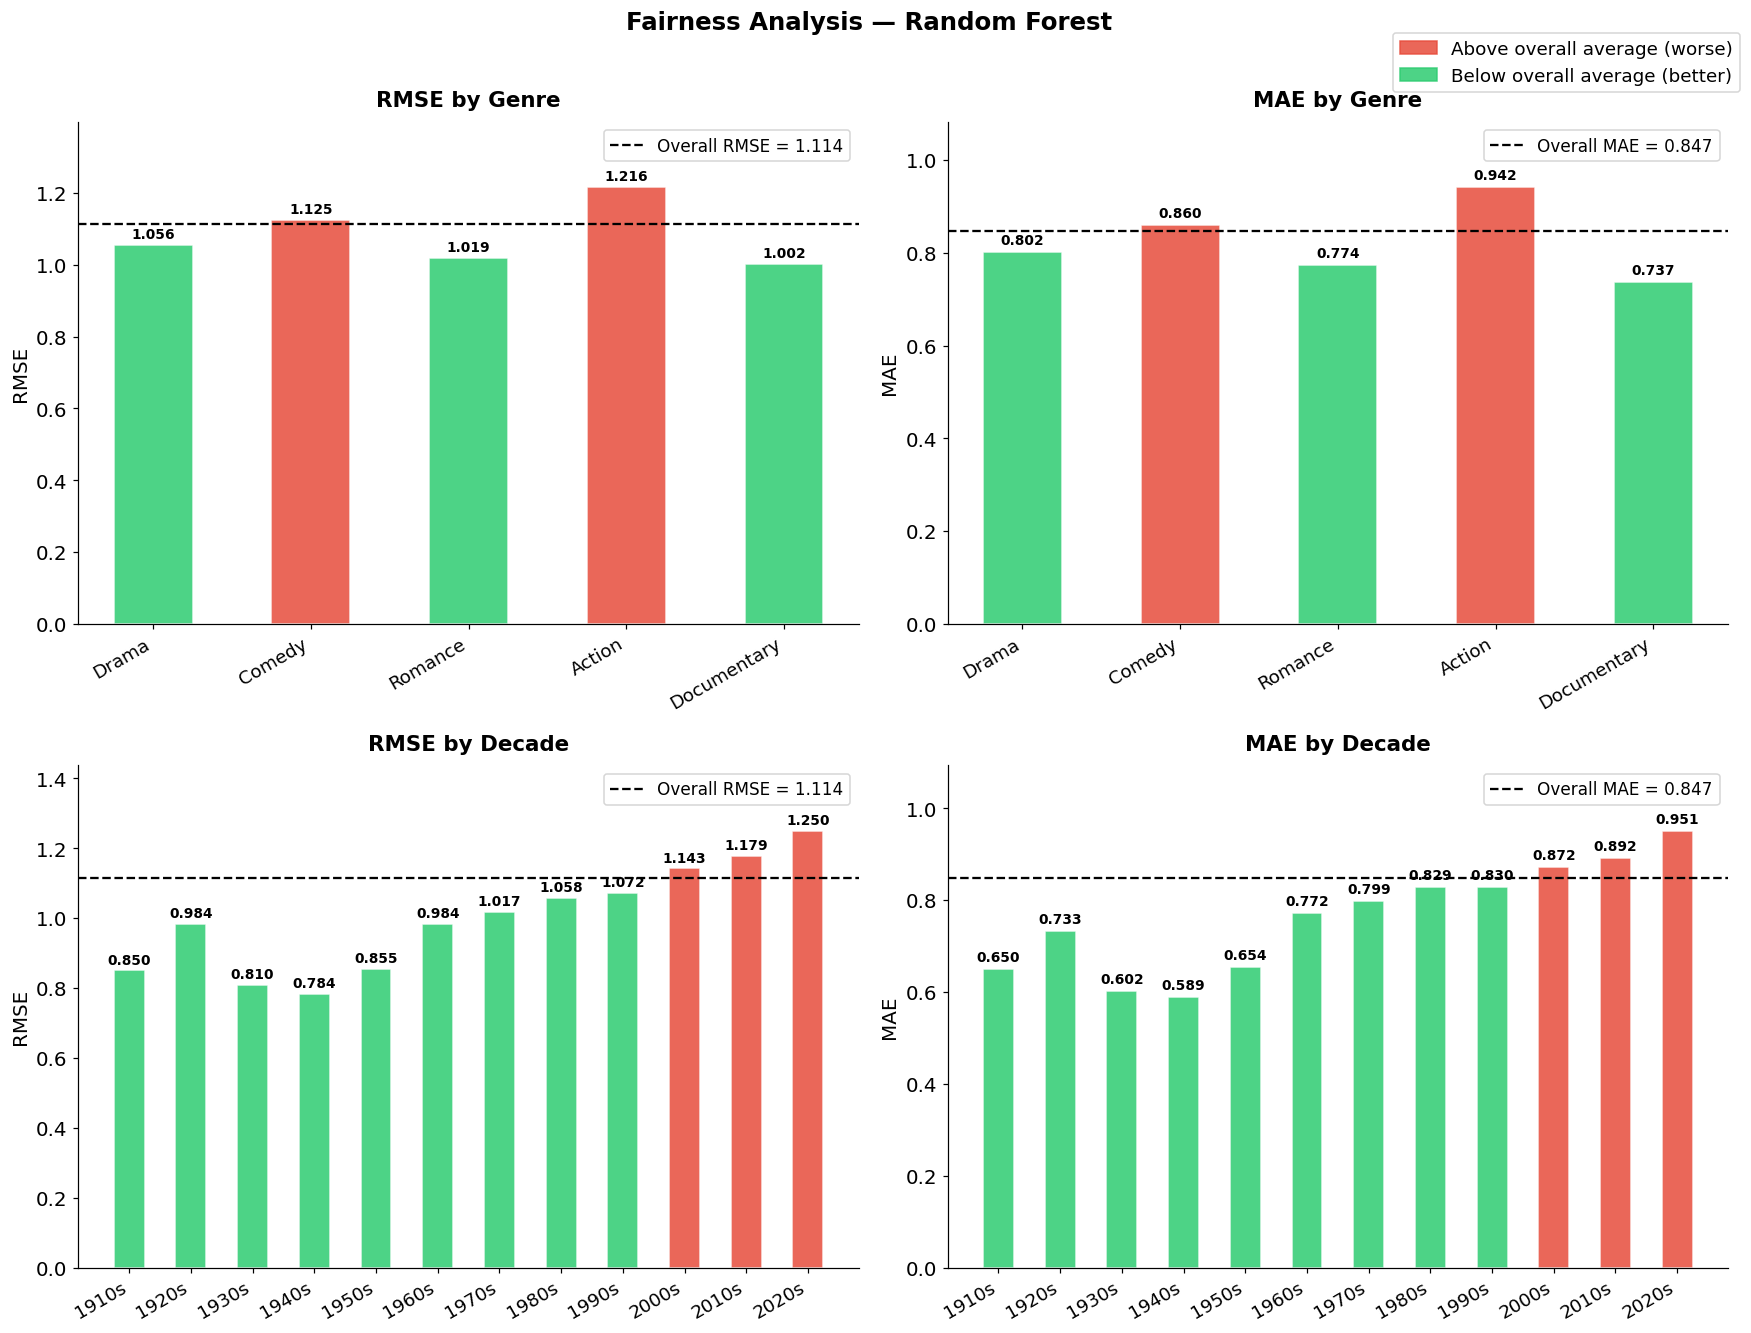

In [60]:
def plot_fairness(ax, values, labels, overall, title, ylabel, fontsize_labels=12):
    colors = [RED if v > overall else GREEN for v in values]
    x = np.arange(len(values))
    bars = ax.bar(x, values, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    ax.axhline(overall, color='black', linestyle='--', linewidth=1.5,
               label=f'Overall {ylabel} = {overall:.3f}')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=fontsize_labels)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.15)
    ax.legend(fontsize=11)

# ── הגרפים ──────────────────────────────────────────────────────
overall_rmse, overall_mae = calc_metrics(fairness_df['y_true'], fairness_df['y_pred_rf'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_fairness(axes[0,0], genre_df['RMSE'],  genre_df.index,  overall_rmse, 'RMSE by Genre',  'RMSE')
plot_fairness(axes[0,1], genre_df['MAE'],   genre_df.index,  overall_mae,  'MAE by Genre',   'MAE')
plot_fairness(axes[1,0], decade_df['RMSE'], [str(d)+'s' for d in decade_df.index], overall_rmse, 'RMSE by Decade', 'RMSE')
plot_fairness(axes[1,1], decade_df['MAE'],  [str(d)+'s' for d in decade_df.index], overall_mae,  'MAE by Decade',  'MAE')

red_patch   = mpatches.Patch(color=RED,   alpha=0.85, label='Above overall average (worse)')
green_patch = mpatches.Patch(color=GREEN, alpha=0.85, label='Below overall average (better)')
fig.legend(handles=[red_patch, green_patch], loc='upper right', fontsize=12,
           frameon=True, bbox_to_anchor=(1.0, 1.0))

plt.suptitle('Fairness Analysis — Random Forest', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fairness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()